# MCP Workshop

## Building a Simple SQLite MCP Server and Calling It from the Notebook

This notebook stays aligned with the deck scope from slides 25-40.

We will cover:

- What MCP is
- Why MCP exists
- How MCP works end to end
- MCP vs APIs
- A simple SQLite example
- A basic Python MCP server
- Running and calling the MCP server from inside the notebook
- Connecting the same server to Cursor and Claude Desktop
- Visualizing the same SQLite data with `matplotlib`


## Section 1: Setup Notes

Important note for the MCP SDK:

- The current official Python MCP SDK expects **Python 3.10+**.
- For this workshop, we will use `/opt/anaconda3/bin/python3` for the MCP server.
- The notebook kernel can still be different, but the server process itself should use the correct interpreter.

Teaching reminder:

- **Claude Desktop / Cursor** = host app with an MCP client
- **Our Python program** = MCP server
- **SQLite queries** = tools exposed by the server


In [1]:
# Uncomment if your environment still needs packages.
# %pip install pandas matplotlib python-dotenv langchain-openai langchain-core

print("Setup cell ready.")


Setup cell ready.


## Section 2: Create a Small SQLite Database

We will create a tiny sales database with dummy data so the MCP demo feels concrete.


In [2]:
import json
import os
import sqlite3
import subprocess
import textwrap
import time
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

DB_PATH = Path("mcp_demo_sales.db")

sample_rows = [
    ("2025-01", "Laptop", "North", 12, 120000),
    ("2025-01", "Mouse", "North", 40, 20000),
    ("2025-01", "Keyboard", "West", 25, 37500),
    ("2025-02", "Laptop", "South", 10, 100000),
    ("2025-02", "Monitor", "West", 14, 56000),
    ("2025-02", "Mouse", "East", 35, 17500),
    ("2025-03", "Laptop", "North", 15, 150000),
    ("2025-03", "Keyboard", "South", 18, 27000),
    ("2025-03", "Monitor", "East", 12, 48000),
    ("2025-04", "Laptop", "West", 9, 90000),
    ("2025-04", "Mouse", "South", 42, 21000),
    ("2025-04", "Keyboard", "North", 20, 30000)
]

with sqlite3.connect(DB_PATH) as conn:
    conn.execute("DROP TABLE IF EXISTS sales")
    conn.execute(
        """
        CREATE TABLE sales (
            month TEXT,
            product TEXT,
            region TEXT,
            units INTEGER,
            revenue REAL
        )
        """
    )
    conn.executemany(
        "INSERT INTO sales (month, product, region, units, revenue) VALUES (?, ?, ?, ?, ?)",
        sample_rows,
    )
    conn.commit()

print(f"Created SQLite database at: {DB_PATH.resolve()}")


Created SQLite database at: /Users/divijbajaj/Library/CloudStorage/OneDrive-Personal/Personal_Projects/agents/mcp_demo_sales.db


In [3]:
with sqlite3.connect(DB_PATH) as conn:
    sales_df = pd.read_sql_query("SELECT * FROM sales", conn)
    monthly_df = pd.read_sql_query(
        "SELECT month, ROUND(SUM(revenue), 2) AS revenue FROM sales GROUP BY month ORDER BY month",
        conn,
    )
    top_products_df = pd.read_sql_query(
        "SELECT product, ROUND(SUM(revenue), 2) AS revenue FROM sales GROUP BY product ORDER BY revenue DESC",
        conn,
    )

display(sales_df)
display(monthly_df)
display(top_products_df)


,month,product,region,units,revenue
0,2025-01,Laptop,North,12,120000.0
1,2025-01,Mouse,North,40,20000.0
2,2025-01,Keyboard,West,25,37500.0
3,2025-02,Laptop,South,10,100000.0
4,2025-02,Monitor,West,14,56000.0
5,2025-02,Mouse,East,35,17500.0
6,2025-03,Laptop,North,15,150000.0
7,2025-03,Keyboard,South,18,27000.0
8,2025-03,Monitor,East,12,48000.0
9,2025-04,Laptop,West,9,90000.0


,month,revenue
0,2025-01,177500.0
1,2025-02,173500.0
2,2025-03,225000.0
3,2025-04,141000.0


,product,revenue
0,Laptop,460000.0
1,Monitor,104000.0
2,Keyboard,94500.0
3,Mouse,58500.0


## Section 3: Visualize the Data Locally

This gives the students a quick visual before we move into MCP.


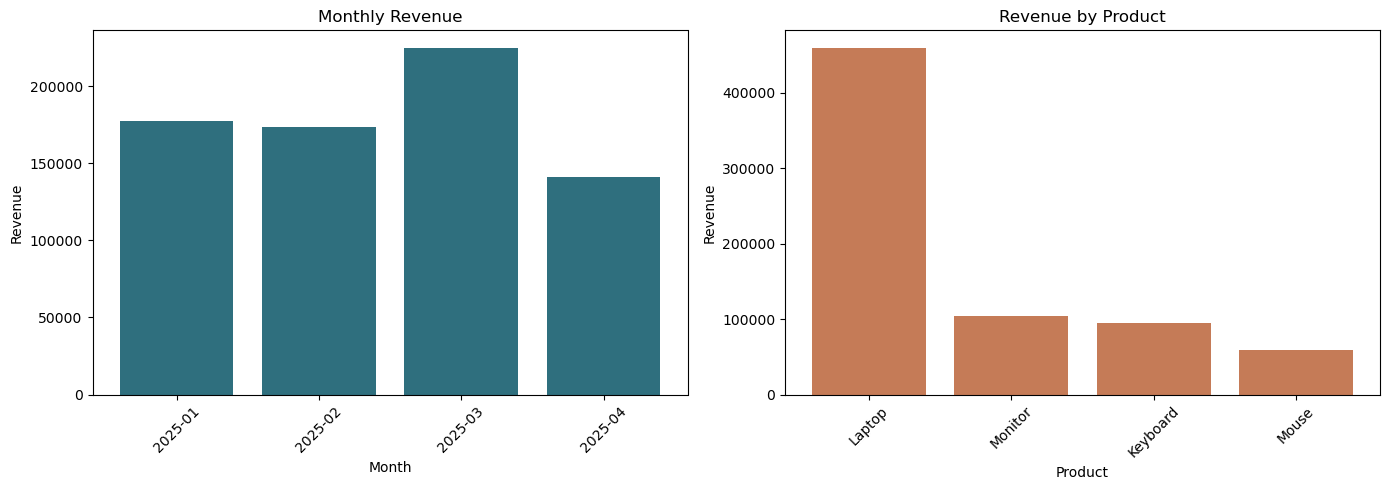

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(monthly_df["month"], monthly_df["revenue"], color="#2f6f7e")
axes[0].set_title("Monthly Revenue")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Revenue")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(top_products_df["product"], top_products_df["revenue"], color="#c57b57")
axes[1].set_title("Revenue by Product")
axes[1].set_xlabel("Product")
axes[1].set_ylabel("Revenue")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## Section 4: MCP Mental Model

Use this explanation while teaching:

```text
User -> Model -> MCP Client -> MCP Server -> SQLite Tool -> JSON Result -> Model -> Answer
```

For this notebook:

- `mcp_sqlite_server.py` = MCP server
- SQLite query functions = tools
- JSON dictionaries = structured results
- direct notebook calls = raw MCP protocol demo
- Claude Desktop / Cursor = host apps that can call the same server


In [5]:
server_code = textwrap.dedent(
    '''
    import sqlite3
    from pathlib import Path
    from mcp.server.fastmcp import FastMCP

    DB_PATH = Path(__file__).with_name("mcp_demo_sales.db")
    mcp = FastMCP("sqlite-sales-demo", json_response=True)

    def fetch_rows(query: str, params: tuple = ()) -> list[dict]:
        with sqlite3.connect(DB_PATH) as conn:
            conn.row_factory = sqlite3.Row
            rows = conn.execute(query, params).fetchall()
            return [dict(row) for row in rows]

    @mcp.tool()
    def list_tables() -> dict:
        """Return all SQLite table names in the demo database."""
        rows = fetch_rows(
            "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name"
        )
        return {"tables": rows, "table_count": len(rows)}

    @mcp.tool()
    def show_sample_sales(limit: int = 5) -> dict:
        """Return a few sample sales rows."""
        safe_limit = max(1, min(limit, 20))
        rows = fetch_rows(
            "SELECT month, product, region, units, revenue FROM sales LIMIT ?",
            (safe_limit,),
        )
        return {"rows": rows, "row_count": len(rows)}

    @mcp.tool()
    def monthly_revenue() -> dict:
        """Return monthly revenue totals."""
        rows = fetch_rows(
            """
            SELECT month, ROUND(SUM(revenue), 2) AS revenue
            FROM sales
            GROUP BY month
            ORDER BY month
            """
        )
        return {"rows": rows, "row_count": len(rows), "metric": "monthly_revenue"}

    @mcp.tool()
    def top_products(limit: int = 5) -> dict:
        """Return the top products by total revenue."""
        safe_limit = max(1, min(limit, 10))
        rows = fetch_rows(
            """
            SELECT product, ROUND(SUM(revenue), 2) AS revenue
            FROM sales
            GROUP BY product
            ORDER BY revenue DESC
            LIMIT ?
            """,
            (safe_limit,),
        )
        return {"rows": rows, "row_count": len(rows), "metric": "top_products"}

    if __name__ == "__main__":
        mcp.run()
    '''
)

server_path = Path("mcp_sqlite_server.py")
server_path.write_text(server_code, encoding="utf-8")

print(f"Created MCP server file at: {server_path.resolve()}")


Created MCP server file at: /Users/divijbajaj/Library/CloudStorage/OneDrive-Personal/Personal_Projects/agents/mcp_sqlite_server.py


## Section 5: Server Config Snippets

These are the local config snippets for Cursor and Claude Desktop.


In [6]:
MCP_PYTHON_PATH = "/opt/anaconda3/bin/python3"
server_abs_path = str(server_path.resolve())

cursor_config = {
    "mcpServers": {
        "sqlite-sales-demo": {
            "command": MCP_PYTHON_PATH,
            "args": [server_abs_path]
        }
    }
}

claude_desktop_config = {
    "mcpServers": {
        "sqlite-sales-demo": {
            "command": MCP_PYTHON_PATH,
            "args": [server_abs_path]
        }
    }
}

print("Cursor config snippet:\n")
print(json.dumps(cursor_config, indent=2))

print("\nClaude Desktop config snippet:\n")
print(json.dumps(claude_desktop_config, indent=2))


Cursor config snippet:

{
  "mcpServers": {
    "sqlite-sales-demo": {
      "command": "/opt/anaconda3/bin/python3",
      "args": [
        "/Users/divijbajaj/Library/CloudStorage/OneDrive-Personal/Personal_Projects/agents/mcp_sqlite_server.py"
      ]
    }
  }
}

Claude Desktop config snippet:

{
  "mcpServers": {
    "sqlite-sales-demo": {
      "command": "/opt/anaconda3/bin/python3",
      "args": [
        "/Users/divijbajaj/Library/CloudStorage/OneDrive-Personal/Personal_Projects/agents/mcp_sqlite_server.py"
      ]
    }
  }
}


## Section 6: Run and Call the MCP Server Inside the Notebook

This is the best way to demo the raw MCP protocol before switching to Claude Desktop.

Flow:

1. Start the MCP server as a background process
2. Send `initialize`
3. Send `tools/list`
4. Send `tools/call`

That gives students a direct view of what the client is doing under the hood.


In [12]:
helper_client_code = textwrap.dedent(
    """
    import asyncio
    import json
    import sys
    from mcp import ClientSession, StdioServerParameters
    from mcp.client.stdio import stdio_client

    def dump_content_item(item):
        if hasattr(item, "model_dump"):
            return item.model_dump(mode="json")
        return str(item)

    async def main():
        action = sys.argv[1]
        python_path = sys.argv[2]
        server_path = sys.argv[3]
        arguments = json.loads(sys.argv[4]) if len(sys.argv) > 4 else {}

        server_params = StdioServerParameters(
            command=python_path,
            args=[server_path],
        )

        async with stdio_client(server_params) as (read, write):
            async with ClientSession(read, write) as session:
                await session.initialize()

                if action == "list_tools":
                    result = await session.list_tools()
                    output = {
                        "tools": [
                            {
                                "name": tool.name,
                                "description": tool.description,
                                "inputSchema": getattr(tool, "inputSchema", None) or getattr(tool, "input_schema", None),
                            }
                            for tool in result.tools
                        ]
                    }
                elif action == "call_tool":
                    tool_name = arguments.pop("__tool_name__")
                    result = await session.call_tool(tool_name, arguments=arguments)
                    output = {
                        "structuredContent": getattr(result, "structuredContent", None),
                        "content": [dump_content_item(item) for item in result.content],
                        "isError": getattr(result, "isError", False),
                    }
                else:
                    raise ValueError(f"Unknown action: {action}")

                print(json.dumps(output))

    if __name__ == "__main__":
        asyncio.run(main())
    """
)

helper_client_path = Path("mcp_notebook_client.py")
helper_client_path.write_text(helper_client_code, encoding="utf-8")

def run_mcp_client(action: str, payload=None):
    payload = payload or {}
    completed = subprocess.run(
        [
            MCP_PYTHON_PATH,
            str(helper_client_path.resolve()),
            action,
            MCP_PYTHON_PATH,
            server_abs_path,
            json.dumps(payload),
        ],
        capture_output=True,
        text=True,
    )
    if completed.returncode != 0:
        raise RuntimeError(completed.stderr or completed.stdout)
    return json.loads(completed.stdout)

print(f"Created helper client at: {helper_client_path.resolve()}")
print("Notebook MCP helper is ready.")


Notebook MCP client helper is ready.


In [13]:
available_tools = run_mcp_client("list_tools")
available_tools


KeyboardInterrupt: 

In [ ]:
sample_payload = run_mcp_client("call_tool", {"__tool_name__": "show_sample_sales", "limit": 5})
sample_payload


RuntimeError: MCP server closed the stream.
[2;36m[03/19/26 20:11:02][0m[2;36m [0m[1;31mERROR   [0m Received exception from stream: [1;36m1[0m     ]8;id=594784;file:///opt/anaconda3/lib/python3.12/site-packages/mcp/server/lowlevel/server.py\[2mserver.py[0m]8;;\[2m:[0m]8;id=601223;file:///opt/anaconda3/lib/python3.12/site-packages/mcp/server/lowlevel/server.py#652\[2m652[0m]8;;\
[2;36m                    [0m         validation error for JSONRPCMessage   [2m             [0m
[2;36m                    [0m           Invalid JSON: expected value at     [2m             [0m
[2;36m                    [0m         line [1;36m1[0m column [1;36m1[0m [1m[[0m[33mtype[0m=[35mjson_invalid[0m,   [2m             [0m
[2;36m                    [0m         [33minput_value[0m=[32m'Content-Length: 185\n'[0m,  [2m             [0m
[2;36m                    [0m         [33minput_type[0m=[35mstr[0m[1m][0m                       [2m             [0m
[2;3

In [ ]:
monthly_payload = run_mcp_client("call_tool", {"__tool_name__": "monthly_revenue"})
monthly_payload


In [ ]:
top_products_payload = run_mcp_client("call_tool", {"__tool_name__": "top_products", "limit": 3})
top_products_payload


### Optional: Let an LLM Decide Which MCP Tool to Use

This section follows the same pattern as your LangGraph workshop: the LLM gets tool schemas, chooses a tool, the notebook executes the tool through MCP, and then the LLM answers.

If you want a simpler live demo, you can skip this section and stop after direct `tools/call`.


### Optional: Let an LLM Decide Which MCP Tool to Use

This section follows the same pattern as your LangGraph workshop: the LLM gets tool schemas, chooses a tool, the notebook executes the tool through MCP, and then the LLM answers.

If you want a simpler live demo, you can skip this section and stop after direct `tools/call`.


In [ ]:
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, ToolMessage

for p in [".env", os.path.join(os.getcwd(), ".env")]:
    if os.path.exists(p):
        load_dotenv(p)
        break
load_dotenv()

USE_OPENROUTER = True

if USE_OPENROUTER:
    API_KEY = os.getenv("OPENROUTER_API_KEY")
    BASE_URL = "https://openrouter.ai/api/v1"
    MODEL_NAME = "openai/gpt-4o-mini"
else:
    API_KEY = os.getenv("OPENAI_API_KEY")
    BASE_URL = None
    MODEL_NAME = "gpt-4o-mini"

llm = ChatOpenAI(
    model=MODEL_NAME,
    openai_api_key=API_KEY,
    openai_api_base=BASE_URL,
    temperature=0,
)

llm_tools = []
for tool in available_tools.get("tools", []):
    llm_tools.append(
        {
            "type": "function",
            "function": {
                "name": tool["name"],
                "description": tool.get("description", ""),
                "parameters": tool.get(
                    "inputSchema",
                    {"type": "object", "properties": {}},
                ),
            },
        }
    )

tool_enabled_llm = llm.bind_tools(llm_tools)
print("LLM tool binding is ready.")


In [ ]:
question = "Which product generated the most revenue? Use the MCP tools if needed."

first_response = tool_enabled_llm.invoke([HumanMessage(content=question)])
first_response.tool_calls


In [ ]:
tool_messages = []

for tool_call in first_response.tool_calls:
    tool_name = tool_call["name"]
    tool_args = tool_call.get("args", {})
    tool_payload = run_mcp_client("call_tool", {"__tool_name__": tool_name, **tool_args})
    tool_messages.append(
        ToolMessage(
            content=json.dumps(tool_payload, indent=2),
            tool_call_id=tool_call["id"],
        )
    )

tool_messages


In [ ]:
final_response = llm.invoke([HumanMessage(content=question), first_response, *tool_messages])
print(final_response.content)


## Section 7: Connection Notes for Cursor and Claude Desktop

### Cursor

Place the generated JSON in `.cursor/mcp.json`, then reload Cursor.

### Claude Desktop

Use the same server file and Python path in Claude Desktop's local MCP config, then fully restart Claude Desktop.

The value of the notebook demo is that students already understand the flow before they see the UI-based tool call.


In [ ]:
with sqlite3.connect(DB_PATH) as conn:
    region_df = pd.read_sql_query(
        "SELECT region, ROUND(SUM(revenue), 2) AS revenue FROM sales GROUP BY region ORDER BY revenue DESC",
        conn,
    )

display(region_df)

plt.figure(figsize=(7, 4))
plt.bar(region_df["region"], region_df["revenue"], color="#5c8d89")
plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.show()


## Section 8: Live Demo Prompts

Use prompts like these once the MCP server is connected in Cursor or Claude Desktop:

- What tables are available in the SQLite demo database?
- Show 5 sample sales rows.
- What is the monthly revenue trend?
- Which product generated the most revenue?
- Which region performed best?

### End-of-Session Summary

This example shows the full MCP idea in one flow:

- a host app contains an MCP client
- the model decides to use a tool
- the client sends a standard request to the server
- the server queries SQLite and returns JSON
- the model uses that result to answer the user

